# Phase 2 — Knowledge Graph Creation Using LLM
**Owner:** M2 — KG Architect | **Input:** `master_dataset.parquet` | **Outputs:** `kg_schema.md`, `kg_triples.json`, `kg_nodes.json`

| Cell | Purpose | LLM? |
|---|---|---|
| 1 | Config & imports | — |
| 2 | Load dataset (auto-detects .parquet / .csv) | — |
| 3 | Define & save KG schema | — |
| 4 | Test OpenAI connection | — |
| 5 | Build structured nodes: Recipe, NutritionProfile, Cuisine, DietaryRestriction, User, Review | ❌ No |
| 6 | Define LLM prompt & helpers | — |
| 7 | LLM extraction loop → Ingredient, Tag, SUBSTITUTES_FOR | ✅ Yes |
| 8 | Ingredient substitutions | ✅ Yes |
| 9 | Save all outputs | — |
| 10 | Validation report | — |
| 11 | Visualisation: interactive network + dashboard + time query demo | — |

---
## Cell 1 — Imports & Configuration
Set `OPENAI_API_KEY` and `DATASET_PATH` before running.

In [1]:
import os
import json
import ast
import re
import time
import logging
from datetime import datetime
from collections import Counter

import pandas as pd
from openai import OpenAI
import os
from google.colab import userdata


# ─── CONFIGURATION ────────────────────────────────────────────────────────────
# Set your OpenAI API key directly here OR use an environment variable
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# Path to your merged dataset from Phase 1
# Path to your merged dataset — supports .parquet or .csv
DATASET_PATH = "master.parquet"

# How many recipes to process (use None to process ALL)
# Start with 500 for testing, increase to 5000 for full run
MAX_RECIPES = 20000

# Save progress every N recipes (in case of crash)
BATCH_SAVE_EVERY = 50

# Output file paths
TRIPLES_OUTPUT   = "kg_triples.json"
NODES_OUTPUT     = "kg_nodes.json"
SCHEMA_OUTPUT    = "kg_schema.md"
LOG_OUTPUT       = "extraction_log.txt"

# LLM model — gpt-3.5-turbo is cheapest; use gpt-4o-mini for better quality
LLM_MODEL = "gpt-3.5-turbo"

# ─── LOGGING SETUP ───────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    handlers=[
        logging.FileHandler(LOG_OUTPUT),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# ─── OPENAI CLIENT ───────────────────────────────────────────────────────────
client = OpenAI(api_key=OPENAI_API_KEY)

logger.info(f"Config loaded. MAX_RECIPES={MAX_RECIPES}, MODEL={LLM_MODEL}")
print("✅ Imports and config ready.")

✅ Imports and config ready.


---
## Cell 2 — Load Dataset
Auto-detects file format by reading file header bytes. Works with `.parquet`, `.csv`, `.tsv`, `.json`.

In [2]:
def safe_parse_list(val):
    """Safely parse a string that looks like a Python list into an actual list."""
    if isinstance(val, list):
        return val
    if pd.isna(val) or val == "" or val is None:
        return []
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else [str(result)]
    except Exception:
        # Fallback: try splitting by comma
        return [x.strip().strip("'\"") for x in str(val).strip("[]").split(",") if x.strip()]


# ─── LOCATE FILE ──────────────────────────────────────────────────────────────
# Searches common locations so you don't have to hardcode the exact path.
def find_dataset(filename):
    """
    Search for the dataset file in common locations.
    Returns the full path if found, raises FileNotFoundError if not.
    """
    import pathlib
    search_roots = [
        pathlib.Path.cwd(),                          # current working directory
        pathlib.Path.cwd().parent,                   # one level up
        pathlib.Path.home(),                         # home directory
        pathlib.Path("/content"),                    # Google Colab default
        pathlib.Path("/content/drive/MyDrive"),      # Google Colab Drive
        pathlib.Path("/kaggle/input"),               # Kaggle
    ]
    # Also search one level deep inside each root
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.append(root / filename)
            for subdir in root.iterdir() if root.exists() else []:
                if subdir.is_dir():
                    candidates.append(subdir / filename)

    for path in candidates:
        if path.exists():
            return str(path)

    # Print all places we looked to help debug
    print("❌ File not found. Searched in:")
    for root in search_roots:
        print(f"   {root}")
    print(f"\nFix: Update DATASET_PATH in Cell 1 to the exact full path of your file.")
    print(f"Example:  DATASET_PATH = '/content/drive/MyDrive/master_dataset.parquet'")
    raise FileNotFoundError(f"Could not find '{filename}' in any common location.")


# ─── AUTO-DETECT & LOAD ───────────────────────────────────────────────────────
def load_dataset(path):
    """
    Load dataset from path. Detects real format by reading file header bytes —
    works even if the file extension is wrong.
    """
    # If path has no directory component, search for it
    if not os.path.exists(path):
        print(f"  '{path}' not found at that path — searching common locations...")
        path = find_dataset(os.path.basename(path))

    print(f"  Found file: {path}")
    print(f"  File size:  {os.path.getsize(path) / 1024:.1f} KB")

    # Read first 8 bytes to detect true format
    with open(path, "rb") as f:
        header = f.read(8)
    print(f"  File header bytes: {header[:8]}")

    # Parquet: starts with PAR1
    if header[:4] == b"PAR1":
        print(f"  Detected format: Parquet ✅")
        return pd.read_parquet(path)

    # Try decoding as text for CSV / TSV / JSON detection
    try:
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            first_line = f.readline()
    except Exception:
        first_line = ""

    if first_line.strip().startswith("[") or first_line.strip().startswith("{"):
        print(f"  Detected format: JSON ✅")
        try:
            return pd.read_json(path)
        except Exception:
            return pd.read_json(path, lines=True)

    if "\t" in first_line:
        print(f"  Detected format: TSV ✅")
        return pd.read_csv(path, sep="\t")

    print(f"  Detected format: CSV ✅")
    return pd.read_csv(path)


df = load_dataset(DATASET_PATH)
logger.info(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ─── PARSE LIST COLUMNS ───────────────────────────────────────────────────────
# These columns may be stored as string representations of lists
list_columns = ["ingredients", "tags", "steps"]
for col in list_columns:
    if col in df.columns:
        df[col] = df[col].apply(safe_parse_list)
        print(f"  Parsed '{col}' — sample: {df[col].iloc[0][:3]}")

# ─── FILL MISSING VALUES ──────────────────────────────────────────────────────
str_cols = ["name", "description", "cuisine"]
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].fillna("")

num_cols = ["minutes", "avg_rating", "num_ratings", "calories", "protein"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# ─── CAP DATASET ──────────────────────────────────────────────────────────────
if MAX_RECIPES is not None:
    df = df.head(MAX_RECIPES)
    print(f"\nCapped to {MAX_RECIPES} recipes for this run.")

print(f"\nFinal working dataset: {len(df)} recipes")
df.head(3)

  Found file: master.parquet
  File size:  417897.9 KB
  File header bytes: b'PAR1\x15\x00\x15\x90'
  Detected format: Parquet ✅

Dataset shape: (1132367, 16)
Columns: ['user_id', 'recipe_id', 'interaction_date', 'rating', 'review', 'name', 'minutes', 'contributor_id', 'submitted_date', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']
  Parsed 'ingredients' — sample: ['great northern beans', 'yellow onion', 'diced green chilies']
  Parsed 'tags' — sample: ['weeknight', 'time-to-make', 'course']
  Parsed 'steps' — sample: ['combine beans , onion , chilies , 1 / 2 teaspoon cumin , garlic powder and broth in crock pot', 'cook on low 8 hours or on high 4 hours', 'stir in cilantro , olive oil and remaining 1 / 2 teaspoon cumin']

Capped to 20000 recipes for this run.

Final working dataset: 20000 recipes


,user_id,recipe_id,interaction_date,rating,review,name,minutes,contributor_id,submitted_date,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,38094,40893,2003-02-17,4.0,Great with a salad. Cooked on top of stove for...,white bean green chile pepper soup,495,1533,2002-09-21,"[weeknight, time-to-make, course, main-ingredi...","[204.8, 5.0, 9.0, 26.0, 24.0, 2.0, 10.0]",4,"[combine beans , onion , chilies , 1 / 2 teasp...",easy soup for the crockpot.,"[great northern beans, yellow onion, diced gre...",9
1,1293707,40893,2011-12-21,5.0,"So simple, so delicious! Great for chilly fall...",white bean green chile pepper soup,495,1533,2002-09-21,"[weeknight, time-to-make, course, main-ingredi...","[204.8, 5.0, 9.0, 26.0, 24.0, 2.0, 10.0]",4,"[combine beans , onion , chilies , 1 / 2 teasp...",easy soup for the crockpot.,"[great northern beans, yellow onion, diced gre...",9
2,8937,44394,2002-12-01,4.0,This worked very well and is EASY. I used not...,devilicious cookie cake delights,20,56824,2002-10-27,"[30-minutes-or-less, time-to-make, course, mai...","[132.3, 11.0, 39.0, 5.0, 4.0, 11.0, 5.0]",5,"[blend together cake mix , oil and eggs, add c...",,"[devil's food cake mix, vegetable oil, eggs, r...",4


---
## Cell 3 — KG Schema
Defines all 8 node types and 10 relationship types. Saves `kg_schema.md` — share with M3 immediately.

In [3]:
# ─── FULL SCHEMA DEFINITION (all columns covered) ────────────────────────────
#
# Node types and where each comes from:
#
#   Recipe           ← id, name, minutes, n_steps, n_ingredients,
#                       description, submitted, avg_rating, num_ratings
#   Ingredient       ← ingredients (list column)          — LLM extracts
#   Cuisine          ← cuisine (derived from tags)        — LLM extracts
#   DietaryRestriction ← tags + boolean diet columns      — LLM extracts
#   Tag              ← tags (list column)                 — LLM extracts
#   NutritionProfile ← calories, fat, sugar, sodium,      — structured (no LLM)
#                       protein, sat_fat, carbs
#   User             ← user_id, contributor_id            — structured (no LLM)
#   Review           ← review text, rating, date          — structured (no LLM)
#
# Relationships:
#   Recipe  -[USES_INGREDIENT]->    Ingredient
#   Recipe  -[BELONGS_TO_CUISINE]-> Cuisine
#   Recipe  -[FITS_DIET]->          DietaryRestriction
#   Recipe  -[HAS_TAG]->            Tag
#   Recipe  -[HAS_NUTRITION]->      NutritionProfile
#   Recipe  -[CONTRIBUTED_BY]->     User
#   Recipe  -[HAS_REVIEW]->         Review
#   Review  -[WRITTEN_BY]->         User
#   Review  -[RATES]->              Recipe        (with rating property)
#   Ingredient -[SUBSTITUTES_FOR]-> Ingredient    (LLM-generated)
# ──────────────────────────────────────────────────────────────────────────────

NODE_TYPES = {
    "Recipe": {
        "description": "A cooking recipe",
        "source": "recipes dataset — direct columns",
        "properties": ["id", "name", "minutes", "n_steps", "n_ingredients",
                        "description", "submitted", "avg_rating", "num_ratings"]
    },
    "Ingredient": {
        "description": "A food ingredient used in a recipe",
        "source": "ingredients list column — LLM extracts clean names",
        "properties": ["name"]
    },
    "Cuisine": {
        "description": "A culinary tradition or style",
        "source": "cuisine column (derived from tags in Phase 1)",
        "properties": ["name"]
    },
    "DietaryRestriction": {
        "description": "A dietary requirement or lifestyle label",
        "source": "tags + vegetarian/vegan/gluten_free/dairy_free columns",
        "properties": ["name"]
    },
    "Tag": {
        "description": "A descriptive label for a recipe (e.g. quick, dinner, italian)",
        "source": "tags list column",
        "properties": ["name"]
    },
    "NutritionProfile": {
        "description": "Nutritional breakdown of a recipe",
        "source": "nutrition/calories/fat/sugar/sodium/protein/sat_fat/carbs columns",
        "properties": ["calories", "fat", "sugar", "sodium", "protein", "sat_fat", "carbs"]
    },
    "User": {
        "description": "A person who contributed or reviewed a recipe",
        "source": "user_id (interactions) + contributor_id (recipes)",
        "properties": ["id", "role"]   # role: 'contributor' or 'reviewer'
    },
    "Review": {
        "description": "A user's written review and numeric rating for a recipe",
        "source": "review, rating, date columns from interactions",
        "properties": ["text", "rating", "date"]
    },
}

RELATIONSHIP_TYPES = [
    {"type": "USES_INGREDIENT",    "from": "Recipe",     "to": "Ingredient",          "source": "LLM", "properties": ["minutes"]},
    {"type": "BELONGS_TO_CUISINE", "from": "Recipe",     "to": "Cuisine",             "source": "LLM", "properties": ["minutes"]},
    {"type": "FITS_DIET",          "from": "Recipe",     "to": "DietaryRestriction",  "source": "LLM", "properties": ["minutes"]},
    {"type": "HAS_TAG",            "from": "Recipe",     "to": "Tag",                 "source": "LLM", "properties": ["minutes"]},
    {"type": "HAS_NUTRITION",      "from": "Recipe",     "to": "NutritionProfile",    "source": "structured", "properties": ["minutes"]},
    {"type": "CONTRIBUTED_BY",     "from": "Recipe",     "to": "User",                "source": "structured", "properties": ["minutes"]},
    {"type": "HAS_REVIEW",         "from": "Recipe",     "to": "Review",              "source": "structured", "properties": ["minutes"]},
    {"type": "WRITTEN_BY",         "from": "Review",     "to": "User",                "source": "structured", "properties": []},
    {"type": "RATES",              "from": "Review",     "to": "Recipe",              "source": "structured", "properties": ["rating"]},
    {"type": "SUBSTITUTES_FOR",    "from": "Ingredient", "to": "Ingredient",          "source": "LLM", "properties": ["score"]},
]

# Set of valid predicates — used for LLM output validation
VALID_PREDICATES = {r["type"] for r in RELATIONSHIP_TYPES}

# ─── WRITE kg_schema.md ───────────────────────────────────────────────────────
from datetime import datetime

lines = [
    "# Knowledge Graph Schema",
    "",
    f"_Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}_",
    "",
    "## Node Types",
    "",
    "| Node Label | Description | Source Column(s) | Properties |",
    "|---|---|---|---|",
]
for label, meta in NODE_TYPES.items():
    props = ", ".join(meta["properties"])
    lines.append(f"| {label} | {meta['description']} | {meta['source']} | {props} |")

lines += [
    "",
    "## Relationship Types",
    "",
    "| Relationship | From | To | How Built | Properties |",
    "|---|---|---|---|---|",
]
for rel in RELATIONSHIP_TYPES:
    props = ", ".join(rel["properties"]) if rel["properties"] else "none"
    lines.append(f"| {rel['type']} | {rel['from']} | {rel['to']} | {rel['source']} | {props} |")

lines += [
    "",
    "## Column Coverage",
    "",
    "| Column | Node / Relationship |",
    "|---|---|",
    "| id | Recipe.id |",
    "| name | Recipe.name |",
    "| minutes | Recipe.minutes |",
    "| contributor_id | User.id + Recipe-[:CONTRIBUTED_BY]->User |",
    "| submitted | Recipe.submitted |",
    "| tags | Tag nodes + Cuisine + DietaryRestriction (via LLM) |",
    "| nutrition / calories / fat / sugar / sodium / protein / sat_fat / carbs | NutritionProfile node |",
    "| n_steps | Recipe.n_steps |",
    "| steps | Recipe property (stored as count; full steps text not a node) |",
    "| description | Recipe.description |",
    "| ingredients | Ingredient nodes + USES_INGREDIENT edges |",
    "| n_ingredients | Recipe.n_ingredients |",
    "| user_id | User.id + WRITTEN_BY edge |",
    "| recipe_id | Links Review → Recipe via RATES edge |",
    "| minutes | Stored on Recipe node AND as property on all Recipe edges for time-based filtering |",
    "| date | Review.date |",
    "| rating | Review.rating + Review-[:RATES {rating}]->Recipe |",
    "| review | Review.text |",
    "| avg_rating | Recipe.avg_rating |",
    "| num_ratings | Recipe.num_ratings |",
]

with open(SCHEMA_OUTPUT, "w") as f:
    f.write("\n".join(lines))

print(f"✅ kg_schema.md saved — {len(NODE_TYPES)} node types, {len(RELATIONSHIP_TYPES)} relationship types")
print()
print("Node types:")
for label, meta in NODE_TYPES.items():
    print(f"   {label:<22} ← {meta['source']}")
print()
print("Relationships:")
for rel in RELATIONSHIP_TYPES:
    print(f"   ({rel['from']}) -[{rel['type']}]-> ({rel['to']})  [{rel['source']}]")


✅ kg_schema.md saved — 8 node types, 10 relationship types

Node types:
   Recipe                 ← recipes dataset — direct columns
   Ingredient             ← ingredients list column — LLM extracts clean names
   Cuisine                ← cuisine column (derived from tags in Phase 1)
   DietaryRestriction     ← tags + vegetarian/vegan/gluten_free/dairy_free columns
   Tag                    ← tags list column
   NutritionProfile       ← nutrition/calories/fat/sugar/sodium/protein/sat_fat/carbs columns
   User                   ← user_id (interactions) + contributor_id (recipes)
   Review                 ← review, rating, date columns from interactions

Relationships:
   (Recipe) -[USES_INGREDIENT]-> (Ingredient)  [LLM]
   (Recipe) -[BELONGS_TO_CUISINE]-> (Cuisine)  [LLM]
   (Recipe) -[FITS_DIET]-> (DietaryRestriction)  [LLM]
   (Recipe) -[HAS_TAG]-> (Tag)  [LLM]
   (Recipe) -[HAS_NUTRITION]-> (NutritionProfile)  [structured]
   (Recipe) -[CONTRIBUTED_BY]-> (User)  [structured]
   (Rec

---
## Cell 4 — Test OpenAI Connection
Send one tiny call to confirm API key works before running the expensive loop.

In [4]:
def test_openai_connection():
    """Send a tiny test message to confirm the API key and connection work."""
    try:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": "Reply with just the word: OK"}],
            max_tokens=5,
            temperature=0
        )
        reply = response.choices[0].message.content.strip()
        print(f"✅ OpenAI connection successful. Model replied: '{reply}'")
        return True
    except Exception as e:
        print(f"❌ OpenAI connection FAILED: {e}")
        print("   Check your OPENAI_API_KEY in Cell 1.")
        return False

test_openai_connection()

✅ OpenAI connection successful. Model replied: 'OK'


True

---
## Cell 5 — Build Structured Nodes (No LLM)

All 6 steps run here. No API calls — fast and free.

| Step | Nodes built | Source columns |
|---|---|---|
| A | Recipe | name, id, minutes, description, avg_rating |
| B | NutritionProfile + HAS_NUTRITION | calories, fat, sugar, sodium, protein |
| C | Cuisine + BELONGS_TO_CUISINE | tags (35 cuisine keywords, rule-based) |
| D | DietaryRestriction + FITS_DIET | tags (21 diet keywords, rule-based) |
| E | User (contributors) + CONTRIBUTED_BY | contributor_id |
| F | Review + User (reviewers) + HAS_REVIEW / WRITTEN_BY / RATES | user_id, rating, review, date |

In [5]:
# ─── INITIALISE TRIPLE & NODE STORES ─────────────────────────────────────────
# These lists accumulate ALL triples and nodes across all cells.
# Cell 7 (LLM loop) will append to these same lists.
all_triples = []
all_nodes_dict = {}   # key: "Label:name_or_id" → node dict  (deduplication)

def add_node(label, name_or_id, properties=None):
    """Add a unique node to all_nodes_dict. Skips if already present."""
    key = f"{label}:{name_or_id}"
    if key not in all_nodes_dict:
        all_nodes_dict[key] = {
            "label": label,
            "name": str(name_or_id),
            "properties": properties or {}
        }

def add_triple(subj_label, subj_name, predicate, obj_label, obj_name, properties=None):
    """Append a triple to all_triples."""
    all_triples.append({
        "subject_label": subj_label,
        "subject_name":  str(subj_name),
        "predicate":     predicate,
        "object_label":  obj_label,
        "object_name":   str(obj_name),
        "properties":    properties or {}
    })

def safe_int(val, default=0):
    try: return int(float(val))
    except: return default

def safe_float(val, default=0.0):
    try: return round(float(val), 2)
    except: return default


# ─── COLUMN AUTO-DETECTION ────────────────────────────────────────────────────
print("Columns in your dataset:")
print(f"  {list(df.columns)}")
print()

def find_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ID_COL      = find_col(["id", "recipe_id", "ID", "RecipeId"])
NAME_COL    = find_col(["name", "Name", "title", "recipe_name", "RecipeName"])
MINUTES_COL = find_col(["minutes", "cook_time", "CookTime", "total_time", "time"])
STEPS_COL   = find_col(["n_steps", "steps_count", "num_steps"])
NINGR_COL   = find_col(["n_ingredients", "ingredient_count", "num_ingredients"])
DESC_COL    = find_col(["description", "Description", "summary"])
SUBMIT_COL  = find_col(["submitted", "submitted_date", "date_submitted", "DatePublished", "created_at"])
AVGRAT_COL  = find_col(["avg_rating", "average_rating", "AggregatedRating", "mean_rating", "rating"])
NUMRAT_COL  = find_col(["num_ratings", "rating_count", "ReviewCount", "n_ratings", "n_reviews"])
TAGS_COL    = find_col(["tags", "Tags", "labels", "keywords"])

print(f"  ID column       → {ID_COL}")
print(f"  Name column     → {NAME_COL}")
print(f"  Minutes column  → {MINUTES_COL}")
print(f"  Avg rating col  → {AVGRAT_COL}")
print(f"  Submitted col   → {SUBMIT_COL}")
print(f"  Tags column     → {TAGS_COL}")
print()

if NAME_COL is None:
    raise ValueError("No recipe name column found. Set NAME_COL manually.")

# Pre-compute avg_rating per recipe from rating column
RATING_SOURCE = AVGRAT_COL if AVGRAT_COL else ("rating" if "rating" in df.columns else None)
if RATING_SOURCE and NAME_COL in df.columns:
    print(f"  Computing avg_rating from column '{RATING_SOURCE}'...")
    _rating_df = df.dropna(subset=[NAME_COL, RATING_SOURCE]).copy()
    _rating_df[RATING_SOURCE] = pd.to_numeric(_rating_df[RATING_SOURCE], errors="coerce")
    _rating_df = _rating_df.dropna(subset=[RATING_SOURCE])
    _agg = _rating_df.groupby(NAME_COL)[RATING_SOURCE].agg(avg_rating="mean", num_ratings="count").reset_index()
    avg_rating_lookup = {row[NAME_COL]: (round(row["avg_rating"], 2), int(row["num_ratings"])) for _, row in _agg.iterrows()}
    print(f"  ✅ Avg ratings computed for {len(avg_rating_lookup)} unique recipes")
else:
    avg_rating_lookup = {}
    print("  ⚠️  No rating column found — avg_rating will be 0")

unique_recipes = df[NAME_COL].dropna().nunique()
total_rows = len(df)
print(f"\n  Dataset: {total_rows} rows → {unique_recipes} unique recipes")
if total_rows > unique_recipes:
    print(f"  (One row per interaction — {total_rows - unique_recipes} duplicate rows merged into avg_rating)")
print()


# ─── CUISINE & DIETARY RESTRICTION KEYWORD MAPS ──────────────────────────────
# Used in BOTH Step A (Recipe node cuisine property) AND Step E (Cuisine/Diet nodes)

CUISINE_MAP = {
    "italian":        "Italian",
    "mexican":        "Mexican",
    "indian":         "Indian",
    "chinese":        "Chinese",
    "japanese":       "Japanese",
    "thai":           "Thai",
    "french":         "French",
    "greek":          "Greek",
    "spanish":        "Spanish",
    "mediterranean":  "Mediterranean",
    "middle-eastern": "Middle Eastern",
    "moroccan":       "Moroccan",
    "turkish":        "Turkish",
    "korean":         "Korean",
    "vietnamese":     "Vietnamese",
    "american":       "American",
    "southern":       "Southern American",
    "cajun":          "Cajun",
    "tex-mex":        "Tex-Mex",
    "caribbean":      "Caribbean",
    "cuban":          "Cuban",
    "brazilian":      "Brazilian",
    "portuguese":     "Portuguese",
    "german":         "German",
    "scandinavian":   "Scandinavian",
    "russian":        "Russian",
    "british":        "British",
    "irish":          "Irish",
    "african":        "African",
    "ethiopian":      "Ethiopian",
    "asian":          "Asian",
    "filipino":       "Filipino",
    "indonesian":     "Indonesian",
    "malaysian":      "Malaysian",
    "pakistani":      "Pakistani",
    "lebanese":       "Lebanese",
}

DIET_MAP = {
    "vegetarian":     "Vegetarian",
    "vegan":          "Vegan",
    "gluten-free":    "GlutenFree",
    "dairy-free":     "DairyFree",
    "low-carb":       "LowCarb",
    "low-fat":        "LowFat",
    "low-calorie":    "LowCalorie",
    "low-sodium":     "LowSodium",
    "low-cholesterol":"LowCholesterol",
    "low-protein":    "LowProtein",
    "high-protein":   "HighProtein",
    "keto":           "Keto",
    "paleo":          "Paleo",
    "halal":          "Halal",
    "kosher":         "Kosher",
    "diabetic":       "DiabeticFriendly",
    "heart-healthy":  "HeartHealthy",
    "whole-30":       "Whole30",
    "sugar-free":     "SugarFree",
    "egg-free":       "EggFree",
    "nut-free":       "NutFree",
}

def extract_cuisine_and_diet(tags_val):
    """Scan a tags value (list or string) and return (cuisine_or_None, [diet_list])."""
    if isinstance(tags_val, list):
        tag_list = [str(t).lower().strip() for t in tags_val]
    elif isinstance(tags_val, str):
        try:
            parsed = ast.literal_eval(tags_val)
            tag_list = [str(t).lower().strip() for t in parsed]
        except Exception:
            tag_list = [t.strip().strip("'\"") for t in tags_val.strip("[]").split(",")]
    else:
        return None, []

    tag_string = " ".join(tag_list)
    cuisine = None
    for keyword, canonical in CUISINE_MAP.items():
        if keyword in tag_string:
            cuisine = canonical
            break
    diets = [canonical for keyword, canonical in DIET_MAP.items() if keyword in tag_string]
    return cuisine, diets


# ─── STEP A: RECIPE NODES ────────────────────────────────────────────────────
print("Building Recipe nodes...")
recipe_count = 0
for _, row in df.iterrows():
    recipe_name = str(row.get(NAME_COL, "")).strip()
    if not recipe_name or recipe_name.lower() == "nan":
        continue

    recipe_id = str(row.get(ID_COL, recipe_name)).strip() if ID_COL else recipe_name
    if not recipe_id or recipe_id.lower() == "nan":
        recipe_id = recipe_name

    # Cuisine from tags (rule-based)
    tags_val = row.get(TAGS_COL, []) if TAGS_COL else []
    cuisine_from_tags, _ = extract_cuisine_and_diet(tags_val)

    props = {
        "id":            recipe_id,
        "minutes":       safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0),
        "n_steps":       safe_int(row.get(STEPS_COL, 0)   if STEPS_COL   else 0),
        "n_ingredients": safe_int(row.get(NINGR_COL, 0)   if NINGR_COL   else 0),
        "description":   str(row.get(DESC_COL, ""))[:500]  if DESC_COL    else "",
        "submitted":     str(row.get(SUBMIT_COL, ""))       if SUBMIT_COL  else "",
        "avg_rating":    avg_rating_lookup.get(recipe_name, (0, 0))[0] if avg_rating_lookup else safe_float(row.get(AVGRAT_COL, 0) if AVGRAT_COL else 0),
        "num_ratings":   avg_rating_lookup.get(recipe_name, (0, 0))[1] if avg_rating_lookup else safe_int(row.get(NUMRAT_COL, 0)   if NUMRAT_COL else 0),
        "cuisine":       cuisine_from_tags or "Unknown",
    }
    add_node("Recipe", recipe_name, props)
    recipe_count += 1

print(f"  ✅ {recipe_count} Recipe nodes (deduplicated to {len([n for n in all_nodes_dict.values() if n['label']=='Recipe'])} unique)")


# ─── STEP B: NUTRITION PROFILE NODES ─────────────────────────────────────────
print("Building NutritionProfile nodes...")
nutrition_cols_map = {"calories": "calories", "fat": "fat", "sugar": "sugar",
                      "sodium": "sodium", "protein": "protein", "sat_fat": "sat_fat", "carbs": "carbs"}

def extract_nutrition(row):
    result = {}
    for key in nutrition_cols_map:
        if key in row and pd.notna(row[key]):
            try: result[key] = round(float(row[key]), 2)
            except: result[key] = 0.0
        else:
            result[key] = 0.0
    if all(v == 0.0 for v in result.values()) and "nutrition" in row:
        raw = row["nutrition"]
        if isinstance(raw, list) and len(raw) >= 7:
            keys = ["calories", "fat", "sugar", "sodium", "protein", "sat_fat", "carbs"]
            for i, k in enumerate(keys):
                try: result[k] = round(float(raw[i]), 2)
                except: result[k] = 0.0
    return result

seen_recipes = set()
nutrition_count = 0
for _, row in df.iterrows():
    recipe_name = str(row.get(NAME_COL, "")).strip()
    if not recipe_name or recipe_name.lower() == "nan" or recipe_name in seen_recipes:
        continue
    seen_recipes.add(recipe_name)
    nutrition = extract_nutrition(row)
    nutri_node_name = f"nutrition_{recipe_name}"
    mins = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
    add_node("NutritionProfile", nutri_node_name, nutrition)
    add_triple("Recipe", recipe_name, "HAS_NUTRITION", "NutritionProfile", nutri_node_name,
               properties={"minutes": mins})
    nutrition_count += 1

print(f"  ✅ {nutrition_count} NutritionProfile nodes + HAS_NUTRITION edges")


# ─── STEP C: CUISINE NODES (rule-based from tags) ────────────────────────────
print("Building Cuisine nodes from tags...")
seen_recipes_c = set()
cuisine_count = 0
for _, row in df.iterrows():
    recipe_name = str(row.get(NAME_COL, "")).strip()
    if not recipe_name or recipe_name.lower() == "nan" or recipe_name in seen_recipes_c:
        continue
    seen_recipes_c.add(recipe_name)
    tags_val = row.get(TAGS_COL, []) if TAGS_COL else []
    cuisine, _ = extract_cuisine_and_diet(tags_val)
    if cuisine:
        mins = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
        add_node("Cuisine", cuisine)
        add_triple("Recipe", recipe_name, "BELONGS_TO_CUISINE", "Cuisine", cuisine,
                   properties={"minutes": mins})
        cuisine_count += 1

print(f"  ✅ {cuisine_count} BELONGS_TO_CUISINE edges  ({len([n for n in all_nodes_dict.values() if n['label']=="Cuisine"])} unique cuisines)")


# ─── STEP D: DIETARY RESTRICTION NODES (rule-based from tags) ────────────────
print("Building DietaryRestriction nodes from tags...")
seen_recipes_d = set()
diet_count = 0
for _, row in df.iterrows():
    recipe_name = str(row.get(NAME_COL, "")).strip()
    if not recipe_name or recipe_name.lower() == "nan":
        continue
    tags_val = row.get(TAGS_COL, []) if TAGS_COL else []
    _, diets = extract_cuisine_and_diet(tags_val)
    mins = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
    for diet in diets:
        add_node("DietaryRestriction", diet)
        add_triple("Recipe", recipe_name, "FITS_DIET", "DietaryRestriction", diet,
                   properties={"minutes": mins})
        diet_count += 1

print(f"  ✅ {diet_count} FITS_DIET edges  ({len([n for n in all_nodes_dict.values() if n['label']=="DietaryRestriction"])} unique dietary restrictions)")


# ─── STEP E: USER NODES (contributors) ───────────────────────────────────────
print("Building User nodes from contributor_id...")
contributor_count = 0
if "contributor_id" in df.columns:
    for _, row in df.iterrows():
        recipe_name    = str(row.get(NAME_COL, "")).strip()
        contributor_id = str(row.get("contributor_id", "")).strip()
        if not contributor_id or contributor_id == "nan" or not recipe_name or recipe_name.lower() == "nan":
            continue
        add_node("User", contributor_id, {"id": contributor_id, "role": "contributor"})
        mins = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
        add_triple("Recipe", recipe_name, "CONTRIBUTED_BY", "User", contributor_id,
                   properties={"minutes": mins})
        contributor_count += 1
print(f"  ✅ {contributor_count} CONTRIBUTED_BY edges")


# ─── STEP F: REVIEW + USER NODES (from interactions) ─────────────────────────
print("Building Review and User nodes from interactions...")
has_interactions = all(col in df.columns for col in ["user_id", "rating"])
has_review_text  = "review" in df.columns
review_count = 0
user_reviewer_count = 0

if has_interactions:
    interaction_rows = df.dropna(subset=["user_id", "rating"])
    for _, row in interaction_rows.iterrows():
        user_id     = str(row.get("user_id", "")).strip()
        recipe_name = str(row.get(NAME_COL, "")).strip()
        rating_val  = row.get("rating", None)
        review_text = str(row.get("review", "")).strip() if has_review_text else ""
        date_val    = str(row.get("interaction_date", row.get("date", ""))).strip()

        if not user_id or user_id == "nan" or not recipe_name or recipe_name.lower() == "nan":
            continue
        try:
            rating_float = float(rating_val)
        except (TypeError, ValueError):
            continue

        add_node("User", user_id, {"id": user_id, "role": "reviewer"})
        user_reviewer_count += 1
        review_node_name = f"review_{user_id}_{recipe_name[:40]}"
        add_node("Review", review_node_name, {
            "text":   review_text[:1000],
            "rating": rating_float,
            "date":   date_val,
        })
        mins = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
        add_triple("Recipe", recipe_name, "HAS_REVIEW",  "Review", review_node_name, properties={"minutes": mins})
        add_triple("Review", review_node_name, "WRITTEN_BY", "User", user_id)
        add_triple("Review", review_node_name, "RATES", "Recipe", recipe_name, properties={"rating": rating_float, "minutes": mins})
        review_count += 1
else:
    print("  ⚠️  No user_id / rating columns found — skipping Review nodes.")

print(f"  ✅ {review_count} Review nodes")
print(f"  ✅ {user_reviewer_count} reviewer User nodes")


# ─── SUMMARY ─────────────────────────────────────────────────────────────────
from collections import Counter
print()
print("─" * 50)
print("Structured nodes built so far:")
label_counts = Counter(v["label"] for v in all_nodes_dict.values())
for label, cnt in sorted(label_counts.items()):
    print(f"   {label:<25} {cnt}")
print(f"\nStructured triples built so far: {len(all_triples)}")
print("─" * 50)
print("\nReady for Cell 6 — LLM extraction will ADD to these lists.")


Columns in your dataset:
  ['user_id', 'recipe_id', 'interaction_date', 'rating', 'review', 'name', 'minutes', 'contributor_id', 'submitted_date', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

  ID column       → recipe_id
  Name column     → name
  Minutes column  → minutes
  Avg rating col  → rating
  Submitted col   → submitted_date
  Tags column     → tags

  Computing avg_rating from column 'rating'...
  ✅ Avg ratings computed for 3872 unique recipes

  Dataset: 20000 rows → 3872 unique recipes
  (One row per interaction — 16128 duplicate rows merged into avg_rating)

Building Recipe nodes...
  ✅ 20000 Recipe nodes (deduplicated to 3872 unique)
Building NutritionProfile nodes...
  ✅ 3872 NutritionProfile nodes + HAS_NUTRITION edges
Building Cuisine nodes from tags...
  ✅ 1337 BELONGS_TO_CUISINE edges  (21 unique cuisines)
Building DietaryRestriction nodes from tags...
  ✅ 27342 FITS_DIET edges  (15 unique dietary restrictions)
Building Us

---
## Cell 6 — LLM Prompt & Helpers
Defines system prompt, per-recipe prompt builder, JSON parser (with truncation recovery), and retry logic. **Run the test at the bottom** before starting the full loop.

In [6]:
# ─── SYSTEM PROMPT ────────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are a knowledge graph builder for a recipe database.
Your job is to extract structured entities and relationships from recipe data.

Output ONLY a valid JSON array of triples. Each triple must have exactly these fields:
  - subject_label:  one of [Recipe, Ingredient, Cuisine, DietaryRestriction, Tag]
  - subject_name:   the name of the subject entity (string)
  - predicate:      one of [USES_INGREDIENT, BELONGS_TO_CUISINE, FITS_DIET, HAS_TAG, SUBSTITUTES_FOR]
  - object_label:   one of [Recipe, Ingredient, Cuisine, DietaryRestriction, Tag]
  - object_name:    the name of the object entity (string)
  - properties:     a JSON object (can be empty {}) — ALWAYS include {"minutes": <cooking_time_int>}
                    on every triple where subject_label is Recipe

Rules:
1. Use ONLY the predicate types listed above — no others.
2. Ingredient names must be clean: lowercase, no quantities, no units (e.g. 'garlic' not '3 cloves garlic').
3. Cuisine must be a single word or short phrase (e.g. 'Italian', 'Mexican', 'Asian').
4. DietaryRestriction must be one of: Vegetarian, Vegan, GlutenFree, DairyFree, Keto, Paleo, Halal, LowCalorie.
5. Tags must be short lowercase strings (e.g. 'pasta', 'quick', 'dinner').
6. ALWAYS add {"minutes": <int>} to properties for every Recipe-origin triple.
7. Do NOT include the word 'null', empty strings, or any extra commentary.
8. Return ONLY the JSON array. No markdown, no explanation."""


def build_recipe_prompt(row):
    """Build the user prompt for a single recipe row from the DataFrame."""
    name        = str(row.get(NAME_COL, "")).strip()
    minutes     = row.get(MINUTES_COL, 0) if MINUTES_COL else 0
    cuisine     = str(row.get("cuisine", "")).strip()
    description = str(row.get(DESC_COL, "")).strip()[:300] if DESC_COL else ""

    # Ingredients — already parsed to list in Cell 2
    ingredients = row.get("ingredients", [])
    if not isinstance(ingredients, list):
        ingredients = safe_parse_list(ingredients)
    # Clean ingredient strings: strip quantities
    cleaned_ingredients = []
    for ing in ingredients[:20]:  # cap at 20 per recipe
        ing_clean = re.sub(r"^[\d\s/½¼¾⅓⅔.]+", "", str(ing)).strip()
        ing_clean = re.sub(r"^(cup|tablespoon|teaspoon|tbsp|tsp|oz|lb|g|kg|ml|l|pinch|clove|slice|medium|large|small|pound|ounce|inch|can|package|bunch|head|piece|stalk)s?\b\s*",
                           "", ing_clean, flags=re.IGNORECASE).strip()
        if ing_clean:
            cleaned_ingredients.append(ing_clean.lower())

    # Tags — cap at 10
    tags = row.get("tags", [])
    if not isinstance(tags, list):
        tags = safe_parse_list(tags)
    tags = [str(t).lower().strip() for t in tags[:10]]

    # Dietary flags — check boolean columns if present
    diet_flags = []
    diet_map = {
        "vegetarian": "Vegetarian",
        "vegan": "Vegan",
        "gluten_free": "GlutenFree",
        "gluten-free": "GlutenFree",
        "dairy_free": "DairyFree",
        "dairy-free": "DairyFree",
        "keto": "Keto",
        "paleo": "Paleo",
    }
    for col, label in diet_map.items():
        if col in row and row[col] == True:
            diet_flags.append(label)
    # Also check from tags
    for tag in tags:
        for key, label in diet_map.items():
            if key.replace("_", "-") in tag or key.replace("-", "_") in tag:
                if label not in diet_flags:
                    diet_flags.append(label)

    prompt = f"""Extract knowledge graph triples from this recipe.
IMPORTANT: Add \"minutes\": {int(minutes)} to properties on ALL triples where subject is the Recipe.

Extract knowledge graph triples from this recipe:

Recipe name: {name}
Cooking time: {int(minutes)} minutes
Cuisine: {cuisine if cuisine else 'unknown'}
Ingredients: {', '.join(cleaned_ingredients)}
Tags: {', '.join(tags)}
Dietary flags: {', '.join(diet_flags) if diet_flags else 'none detected'}
Description: {description}

Return a JSON array of triples for this recipe."""
    return prompt


def parse_llm_response(response_text, recipe_name):
    """
    Parse the LLM's raw response into a list of validated triple dicts.
    Returns (valid_triples, error_message_or_None).
    Handles truncated JSON by salvaging all complete objects before the cut-off.
    """
    # Strip markdown code fences if present
    text = response_text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    text = text.strip()

    # ── Attempt 1: parse as-is ────────────────────────────────────────────────
    data = None
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        pass

    # ── Attempt 2: find [...] block anywhere in text ──────────────────────────
    if data is None:
        match = re.search(r"\[.*\]", text, re.DOTALL)
        if match:
            try:
                data = json.loads(match.group())
            except Exception:
                pass

    # ── Attempt 3: response was TRUNCATED — salvage complete objects ──────────
    # The response ends mid-array. Find every complete {...} object individually.
    if data is None:
        # Find the opening bracket
        start = text.find("[")
        if start != -1:
            fragment = text[start:]
            # Extract all complete {...} objects using regex
            object_pattern = re.compile(r'\{[^{}]*\}', re.DOTALL)
            raw_objects = object_pattern.findall(fragment)
            salvaged = []
            for obj_str in raw_objects:
                try:
                    salvaged.append(json.loads(obj_str))
                except Exception:
                    continue
            if salvaged:
                data = salvaged
                # Note: truncation happened but we salvaged what we could

    if data is None:
        return [], f"Could not parse response for recipe '{recipe_name}'"

    if not isinstance(data, list):
        data = [data]   # single object returned instead of array

    # ── Validate each triple ──────────────────────────────────────────────────
    required_keys = {"subject_label", "subject_name", "predicate", "object_label", "object_name"}
    valid_triples = []
    for item in data:
        if not isinstance(item, dict):
            continue
        if not required_keys.issubset(item.keys()):
            continue
        if item["predicate"] not in VALID_PREDICATES:
            continue
        if not str(item["subject_name"]).strip() or not str(item["object_name"]).strip():
            continue
        item["subject_name"] = str(item["subject_name"]).strip()
        item["object_name"]  = str(item["object_name"]).strip()
        if "properties" not in item or not isinstance(item["properties"], dict):
            item["properties"] = {}
        valid_triples.append(item)

    return valid_triples, None


def call_llm(prompt_text, retries=3, backoff=5):
    """
    Call the OpenAI API with retry and exponential backoff.
    Returns (response_text, error_or_None).
    """
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt_text}
                ],
                max_tokens=2000,
                temperature=0  # deterministic output
            )
            return response.choices[0].message.content, None
        except Exception as e:
            wait = backoff * (2 ** attempt)
            logger.warning(f"API error (attempt {attempt+1}/{retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    return None, f"All {retries} API attempts failed"


# ─── QUICK TEST: run the prompt on 1 recipe to verify output format ───────────
print("Testing prompt on first recipe...")
sample_row = df.iloc[0]
sample_prompt = build_recipe_prompt(sample_row)
print("--- PROMPT PREVIEW ---")
print(sample_prompt)
print("\n--- CALLING API ---")
sample_response, err = call_llm(sample_prompt)
if err:
    print(f"❌ Error: {err}")
else:
    triples, parse_err = parse_llm_response(sample_response, sample_row.get("name", "unknown"))
    if parse_err:
        print(f"⚠️  Parse warning: {parse_err}")
        print(f"   Raw response: {sample_response[:500]}")
    else:
        print(f"✅ Got {len(triples)} valid triples from first recipe:")
        for t in triples[:5]:
            print(f"   ({t['subject_label']}: {t['subject_name']}) -[{t['predicate']}]-> ({t['object_label']}: {t['object_name']})")

Testing prompt on first recipe...
--- PROMPT PREVIEW ---
Extract knowledge graph triples from this recipe.
IMPORTANT: Add "minutes": 495 to properties on ALL triples where subject is the Recipe.

Extract knowledge graph triples from this recipe:

Recipe name: white bean   green chile pepper soup
Cooking time: 495 minutes
Cuisine: unknown
Ingredients: great northern beans, yellow onion, diced green chilies, ground cumin, garlic powder, fat-free chicken broth, fresh cilantro leaves, extra virgin olive oil, sour cream
Tags: weeknight, time-to-make, course, main-ingredient, preparation, occasion, soups-stews, beans, vegetables, easy
Dietary flags: none detected
Description: easy soup for the crockpot.

Return a JSON array of triples for this recipe.

--- CALLING API ---
✅ Got 19 valid triples from first recipe:
   (Recipe: white bean green chile pepper soup) -[USES_INGREDIENT]-> (Ingredient: great northern beans)
   (Recipe: white bean green chile pepper soup) -[USES_INGREDIENT]-> (Ingredi

---
## Cell 7 — LLM Extraction Loop
One API call per **unique** recipe. Saves progress every 50 recipes — safe to re-run if interrupted.

**Cost estimate:**
| Recipes | Approx cost (gpt-3.5-turbo) |
|---|---|
| 500 | ~$0.10 |
| 5,000 | ~$1.00 |
| 20,000 | ~$4.00 |

In [7]:
PROGRESS_FILE = "kg_triples_progress.json"

# ─── RESUME FROM PROGRESS FILE IF IT EXISTS ──────────────────────────────────
# NOTE: all_triples was initialised in Cell 5 (structured nodes).
# We append LLM-extracted triples to the same list.
# processed_ids tracks which recipes the LLM has already handled.
processed_ids = set()

if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        saved = json.load(f)
    llm_triples   = saved.get("triples", [])
    processed_ids = set(saved.get("processed_ids", []))
    # Merge saved LLM triples back in (avoid duplicating structured ones)
    all_triples.extend(llm_triples)
    logger.info(f"Resumed: {len(llm_triples)} LLM triples, {len(processed_ids)} recipes done")
    print(f"▶️  Resuming: {len(llm_triples)} LLM triples already saved, {len(processed_ids)} recipes done")
else:
    print("▶️  Starting LLM extraction (structured nodes already in all_triples from Cell 5)...")

if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        saved = json.load(f)
    all_triples     = saved.get("triples", [])
    processed_ids   = set(saved.get("processed_ids", []))
    logger.info(f"Resumed from progress file: {len(all_triples)} triples, {len(processed_ids)} recipes done")
    print(f"▶️  Resuming: already have {len(all_triples)} triples from {len(processed_ids)} recipes")
else:
    print("▶️  Starting fresh extraction...")

# ─── STATS COUNTERS ──────────────────────────────────────────────────────────
stats = {"success": 0, "failed": 0, "skipped": 0, "total_triples_added": 0}

# ─── MAIN LOOP ────────────────────────────────────────────────────────────────
total = len(df)
for i, (_, row) in enumerate(df.iterrows()):

    recipe_id   = str(row.get(ID_COL, i)) if ID_COL else str(i)
    recipe_name = str(row.get(NAME_COL, f"recipe_{i}"))

    # Skip already-processed recipes (for resume)
    if recipe_id in processed_ids:
        stats["skipped"] += 1
        continue

    # Print progress
    if (i + 1) % 25 == 0 or i == 0:
        print(f"  [{i+1}/{total}]  triples so far: {len(all_triples)}  failed: {stats['failed']}")

    # Build prompt
    prompt = build_recipe_prompt(row)

    # Call LLM
    raw_response, api_err = call_llm(prompt)

    if api_err:
        logger.error(f"SKIP recipe_id={recipe_id} name='{recipe_name}': {api_err}")
        stats["failed"] += 1
        processed_ids.add(recipe_id)
        continue

    # Parse response
    triples, parse_err = parse_llm_response(raw_response, recipe_name)

    if parse_err:
        logger.warning(f"PARSE_ERR recipe_id={recipe_id}: {parse_err}")
        stats["failed"] += 1
    else:
        # Backfill minutes from the dataset row onto any Recipe-origin triple
        # where LLM forgot to add it — guarantees every edge has minutes
        recipe_minutes = safe_int(row.get(MINUTES_COL, 0) if MINUTES_COL else 0)
        for t in triples:
            if t["subject_label"] == "Recipe":
                if "properties" not in t or not isinstance(t.get("properties"), dict):
                    t["properties"] = {}
                if "minutes" not in t["properties"]:
                    t["properties"]["minutes"] = recipe_minutes
        all_triples.extend(triples)
        stats["success"] += 1
        stats["total_triples_added"] += len(triples)

    processed_ids.add(recipe_id)

    # Save progress every BATCH_SAVE_EVERY recipes
    if (i + 1) % BATCH_SAVE_EVERY == 0:
        # Save only the LLM-generated triples to progress file
        llm_only = [t for t in all_triples if t.get("predicate") in
                    {"USES_INGREDIENT","BELONGS_TO_CUISINE","FITS_DIET","HAS_TAG","SUBSTITUTES_FOR"}]
        with open(PROGRESS_FILE, "w") as f:
            json.dump({"triples": llm_only, "processed_ids": list(processed_ids)}, f)
        logger.info(f"Progress saved at recipe {i+1}/{total}")

    # Small delay to avoid hitting rate limits
    time.sleep(0.2)

# Final save of progress file
with open(PROGRESS_FILE, "w") as f:
    json.dump({"triples": all_triples, "processed_ids": list(processed_ids)}, f)

print("\n" + "="*50)
print(f"✅ Extraction complete!")
print(f"   Recipes processed successfully : {stats['success']}")
print(f"   Recipes failed / skipped       : {stats['failed']}")
print(f"   Total triples collected        : {len(all_triples)}")
print("="*50)
logger.info(f"Extraction done. success={stats['success']}, failed={stats['failed']}, triples={len(all_triples)}")

▶️  Starting LLM extraction (structured nodes already in all_triples from Cell 5)...
▶️  Starting fresh extraction...
  [1/20000]  triples so far: 112551  failed: 0
  [100/20000]  triples so far: 113089  failed: 0
  [150/20000]  triples so far: 113488  failed: 0
  [300/20000]  triples so far: 114474  failed: 0
  [325/20000]  triples so far: 114620  failed: 0
  [525/20000]  triples so far: 115525  failed: 0
  [575/20000]  triples so far: 115804  failed: 0
  [650/20000]  triples so far: 116334  failed: 0
  [1000/20000]  triples so far: 117506  failed: 0
  [1250/20000]  triples so far: 118528  failed: 0
  [1350/20000]  triples so far: 119143  failed: 0
  [1650/20000]  triples so far: 119693  failed: 0
  [1725/20000]  triples so far: 119969  failed: 0
  [1975/20000]  triples so far: 121077  failed: 0
  [2150/20000]  triples so far: 121704  failed: 0
  [2475/20000]  triples so far: 123571  failed: 0
  [2500/20000]  triples so far: 123707  failed: 0
  [2525/20000]  triples so far: 123898  fa

KeyboardInterrupt: 

---
## Cell 8 — Ingredient Substitutions
One batch API call for the top 100 most common ingredients. Adds `SUBSTITUTES_FOR` triples.

In [8]:
TOP_N_INGREDIENTS = 100   # How many ingredients to get substitutions for
SUBS_PER_INGREDIENT = 3  # Max substitutes per ingredient

# ─── FIND TOP INGREDIENTS ─────────────────────────────────────────────────────
all_ingredient_names = []
for _, row in df.iterrows():
    ings = row.get("ingredients", [])
    if isinstance(ings, list):
        for ing in ings:
            # Strip quantities
            clean = re.sub(r"^[\d\s/½¼¾.]+", "", str(ing)).strip().lower()
            clean = re.sub(r"^(cup|tablespoon|teaspoon|tbsp|tsp|oz|lb|g|kg|ml|l|pinch|clove|slice|medium|large|small)s?\s+",
                           "", clean, flags=re.IGNORECASE).strip()
            if clean:
                all_ingredient_names.append(clean)

ingredient_counts = Counter(all_ingredient_names)
top_ingredients = [name for name, _ in ingredient_counts.most_common(TOP_N_INGREDIENTS)]
print(f"Top {TOP_N_INGREDIENTS} ingredients found.")
print(f"Most common: {top_ingredients[:10]}")

# ─── SUBSTITUTION PROMPT ──────────────────────────────────────────────────────
SUBS_SYSTEM_PROMPT = """You are a culinary expert helping build a recipe knowledge graph.
For each ingredient given, provide up to 3 reasonable substitutes that work in cooking.
Return ONLY a valid JSON array. Each element must have exactly:
  - ingredient: string (the original ingredient)
  - substitutes: array of strings (substitute names)
No markdown, no explanation, just the JSON array."""

def get_substitutions_batch(ingredient_list):
    """Get substitutions for a batch of ingredients in one API call."""
    ingredients_str = "\n".join(f"- {ing}" for ing in ingredient_list)
    user_msg = f"Provide substitutes for each of these ingredients:\n{ingredients_str}"

    raw, err = call_llm.__wrapped__(user_msg) if hasattr(call_llm, '__wrapped__') else None, None

    # Direct call (bypassing the wrapper to use custom system prompt)
    try:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": SUBS_SYSTEM_PROMPT},
                {"role": "user",   "content": user_msg}
            ],
            max_tokens=2000,
            temperature=0
        )
        raw_text = response.choices[0].message.content.strip()
        # Strip markdown fences
        raw_text = re.sub(r"^```(?:json)?\s*", "", raw_text)
        raw_text = re.sub(r"\s*```$", "", raw_text).strip()
        return json.loads(raw_text), None
    except json.JSONDecodeError:
        match = re.search(r"\[.*\]", raw_text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group()), None
            except Exception as e:
                return [], str(e)
        return [], "JSON parse failed"
    except Exception as e:
        return [], str(e)


# ─── CALL IN CHUNKS OF 20 ─────────────────────────────────────────────────────
substitution_triples = []
chunk_size = 20
chunks = [top_ingredients[i:i+chunk_size] for i in range(0, len(top_ingredients), chunk_size)]

print(f"\nFetching substitutions in {len(chunks)} chunks of {chunk_size}...")
for ci, chunk in enumerate(chunks):
    print(f"  Chunk {ci+1}/{len(chunks)}...")
    subs_data, err = get_substitutions_batch(chunk)
    if err:
        logger.warning(f"Substitution chunk {ci+1} failed: {err}")
        continue

    for item in subs_data:
        if not isinstance(item, dict):
            continue
        ingredient_name = item.get("ingredient", "").strip().lower()
        substitutes     = item.get("substitutes", [])
        if not ingredient_name or not isinstance(substitutes, list):
            continue
        for sub in substitutes[:SUBS_PER_INGREDIENT]:
            sub_name = str(sub).strip().lower()
            if sub_name and sub_name != ingredient_name:
                substitution_triples.append({
                    "subject_label": "Ingredient",
                    "subject_name":  ingredient_name,
                    "predicate":     "SUBSTITUTES_FOR",
                    "object_label":  "Ingredient",
                    "object_name":   sub_name,
                    "properties":    {"score": 0.8}  # default confidence score
                })

    time.sleep(0.5)  # rate limit buffer

# Add substitution triples to main list
all_triples.extend(substitution_triples)

print(f"\n✅ Added {len(substitution_triples)} SUBSTITUTES_FOR triples")
print(f"   Total triples now: {len(all_triples)}")
logger.info(f"Added {len(substitution_triples)} substitution triples. Total: {len(all_triples)}")

Top 100 ingredients found.
Most common: ['salt', 'butter', 'sugar', 'onion', 'water', 'flour', 'pepper', 'eggs', 'baking powder', 'milk']

Fetching substitutions in 5 chunks of 20...
  Chunk 1/5...
  Chunk 2/5...
  Chunk 3/5...
  Chunk 4/5...
  Chunk 5/5...

✅ Added 300 SUBSTITUTES_FOR triples
   Total triples now: 176330


---
## Cell 9 — Save Outputs
Saves `kg_triples.json` and `kg_nodes.json`. These are the handoff files for M3.

In [9]:
# ─── SAVE kg_triples.json ─────────────────────────────────────────────────────
with open(TRIPLES_OUTPUT, "w") as f:
    json.dump(all_triples, f, indent=2)
print(f"✅ Saved {len(all_triples)} triples to '{TRIPLES_OUTPUT}'")

# ─── MERGE LLM NODES INTO all_nodes_dict ─────────────────────────────────────
# The LLM loop added triples but didn't add nodes to all_nodes_dict.
# Extract any new nodes from triples now.
for triple in all_triples:
    for side in [("subject_label", "subject_name"), ("object_label", "object_name")]:
        label_key, name_key = side
        label = triple.get(label_key, "")
        name  = triple.get(name_key, "")
        if label and name:
            key = f"{label}:{name}"
            if key not in all_nodes_dict:
                all_nodes_dict[key] = {"label": label, "name": name, "properties": {}}

# Enrich Recipe nodes with properties from the DataFrame
for _, row in df.iterrows():
    rname = str(row.get(NAME_COL, "")).strip()
    key   = f"Recipe:{rname}"
    if key in all_nodes_dict:
        all_nodes_dict[key]["properties"].update({
            "id":            str(row.get("id", "")),
            "minutes":       int(row.get("minutes", 0)),
            "avg_rating":    float(row.get("avg_rating", 0)),
            "num_ratings":   int(row.get("num_ratings", 0)),
            "calories":      float(row.get("calories", 0)) if "calories" in df.columns else 0,
            "protein":       float(row.get("protein", 0))  if "protein"  in df.columns else 0,
            "cuisine":       str(row.get("cuisine", "")) if "cuisine" in df.columns else "",
            "description":   str(row.get("description", ""))[:300],
        })

all_nodes = list(all_nodes_dict.values())
with open(NODES_OUTPUT, "w") as f:
    json.dump(all_nodes, f, indent=2)

print(f"✅ Saved {len(all_nodes)} unique nodes to '{NODES_OUTPUT}'")
logger.info(f"Saved {len(all_triples)} triples and {len(all_nodes)} nodes to disk")

# Count by label
from collections import Counter
label_counts = Counter(n["label"] for n in all_nodes)
pred_counts  = Counter(t["predicate"] for t in all_triples)

print("\nNode counts by label:")
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"   {label:<25} {count}")

print("\nTriple counts by relationship:")
for pred, count in sorted(pred_counts.items(), key=lambda x: -x[1]):
    print(f"   {pred:<30} {count}")


✅ Saved 176330 triples to 'kg_triples.json'
✅ Saved 44350 unique nodes to 'kg_nodes.json'

Node counts by label:
   Review                    20000
   User                      12280
   Recipe                    4339
   NutritionProfile          3872
   Ingredient                3512
   Tag                       308
   Cuisine                   23
   DietaryRestriction        16

Triple counts by relationship:
   HAS_TAG                        32524
   USES_INGREDIENT                30786
   FITS_DIET                      27452
   CONTRIBUTED_BY                 20000
   HAS_REVIEW                     20000
   WRITTEN_BY                     20000
   RATES                          20000
   HAS_NUTRITION                  3872
   BELONGS_TO_CUISINE             1365
   SUBSTITUTES_FOR                331


---
## Cell 10 — Validation Report
Checks all 8 node types exist, all relationship types are populated, all files are saved.

In [10]:
print("=" * 55)
print("  VALIDATION REPORT")
print("=" * 55)

all_checks_passed = True

# ─── 1. Load files from disk ──────────────────────────────────────────────────
try:
    with open(TRIPLES_OUTPUT) as f:
        loaded_triples = json.load(f)
    print(f"\n✅ {TRIPLES_OUTPUT} loads OK  ({len(loaded_triples)} triples)")
except Exception as e:
    print(f"\n❌ {TRIPLES_OUTPUT} FAILED: {e}")
    all_checks_passed = False
    loaded_triples = []

try:
    with open(NODES_OUTPUT) as f:
        loaded_nodes = json.load(f)
    print(f"✅ {NODES_OUTPUT} loads OK  ({len(loaded_nodes)} nodes)")
except Exception as e:
    print(f"❌ {NODES_OUTPUT} FAILED: {e}")
    all_checks_passed = False
    loaded_nodes = []

# ─── 2. Check required triple fields ─────────────────────────────────────────
required_fields = {"subject_label", "subject_name", "predicate", "object_label", "object_name"}
malformed = [t for t in loaded_triples if not required_fields.issubset(t.keys())]
if malformed:
    print(f"⚠️  {len(malformed)} triples missing required fields")
    all_checks_passed = False
else:
    print(f"✅ All triples have required fields")

# ─── 3. Check all predicates are valid ───────────────────────────────────────
invalid_preds = [t for t in loaded_triples if t.get("predicate") not in VALID_PREDICATES]
if invalid_preds:
    from collections import Counter
    print(f"⚠️  {len(invalid_preds)} triples have invalid predicates: {dict(Counter(t['predicate'] for t in invalid_preds))}")
    all_checks_passed = False
else:
    print(f"✅ All predicates are valid")

# ─── 4. Check all 8 expected node types exist ────────────────────────────────
from collections import Counter
node_label_counts = Counter(n.get("label") for n in loaded_nodes)
pred_counts       = Counter(t.get("predicate") for t in loaded_triples)

expected_node_types = ["Recipe", "Ingredient", "Cuisine", "DietaryRestriction",
                        "Tag", "NutritionProfile", "User", "Review"]
print(f"\nNode type coverage:")
for nt in expected_node_types:
    count = node_label_counts.get(nt, 0)
    mark  = "✅" if count > 0 else "❌"
    print(f"   {mark}  {nt:<22} {count} nodes")
    if count == 0:
        all_checks_passed = False

# ─── 5. Check key relationship types exist ───────────────────────────────────
expected_rels = ["USES_INGREDIENT", "BELONGS_TO_CUISINE", "HAS_NUTRITION",
                  "HAS_REVIEW", "WRITTEN_BY", "CONTRIBUTED_BY", "SUBSTITUTES_FOR"]
print(f"\nRelationship type coverage:")
for rel in expected_rels:
    count = pred_counts.get(rel, 0)
    mark  = "✅" if count > 0 else "❌"
    print(f"   {mark}  {rel:<30} {count} triples")
    if count == 0:
        all_checks_passed = False

# ─── 6. Output file checklist ────────────────────────────────────────────────
print(f"\nOutput files:")
for fname in [SCHEMA_OUTPUT, TRIPLES_OUTPUT, NODES_OUTPUT, LOG_OUTPUT]:
    exists = os.path.exists(fname)
    size   = os.path.getsize(fname) if exists else 0
    mark   = "✅" if exists else "❌"
    print(f"   {mark}  {fname:<30}  {'%.1f KB' % (size/1024) if exists else 'MISSING'}")

# ─── 7. Sample triples ───────────────────────────────────────────────────────
print(f"\nSample triples (2 of each type):")
shown = {}
for t in loaded_triples:
    pred = t.get("predicate")
    if pred not in shown:
        shown[pred] = 0
    if shown[pred] < 2:
        print(f"   ({t['subject_label']}: {t['subject_name'][:30]}) -[{pred}]-> ({t['object_label']}: {t['object_name'][:30]})")
        shown[pred] += 1

# ─── FINAL VERDICT ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
if all_checks_passed:
    print("  ✅ ALL CHECKS PASSED — Ready to hand off to M3")
    print(f"  Total triples : {len(loaded_triples)}")
    print(f"  Total nodes   : {len(loaded_nodes)}")
else:
    print("  ⚠️  SOME CHECKS FAILED — Review warnings above")
print("=" * 55)
print(f"""
Files to send to M3:
  1. kg_schema.md    — Neo4j schema blueprint
  2. kg_triples.json — all extracted triples
  3. kg_nodes.json   — all unique nodes with properties
""")


  VALIDATION REPORT

✅ kg_triples.json loads OK  (176330 triples)
✅ kg_nodes.json loads OK  (44350 nodes)
✅ All triples have required fields
✅ All predicates are valid

Node type coverage:
   ✅  Recipe                 4339 nodes
   ✅  Ingredient             3512 nodes
   ✅  Cuisine                23 nodes
   ✅  DietaryRestriction     16 nodes
   ✅  Tag                    308 nodes
   ✅  NutritionProfile       3872 nodes
   ✅  User                   12280 nodes
   ✅  Review                 20000 nodes

Relationship type coverage:
   ✅  USES_INGREDIENT                30786 triples
   ✅  BELONGS_TO_CUISINE             1365 triples
   ✅  HAS_NUTRITION                  3872 triples
   ✅  HAS_REVIEW                     20000 triples
   ✅  WRITTEN_BY                     20000 triples
   ✅  CONTRIBUTED_BY                 20000 triples
   ✅  SUBSTITUTES_FOR                331 triples

Output files:
   ✅  kg_schema.md                    2.8 KB
   ✅  kg_triples.json                 41339.2 KB
   

---
## Cell 11 — Visualisation
- **Part A** — Interactive pyvis network (`kg_network.html`) — colour-coded nodes, hover tooltips
- **Part B** — Dashboard: node counts, top ingredients, cuisines, cooking time histogram, ratings
- **Part C** — Time query demo: "show me recipes ready in ≤30 minutes"

Loading kg_triples.json and kg_nodes.json...
  Loaded 176330 triples, 44350 nodes

Building interactive network...
  ✅ Saved to 'kg_network.html' — 6 recipes, 173 edges shown



Building dashboard charts...


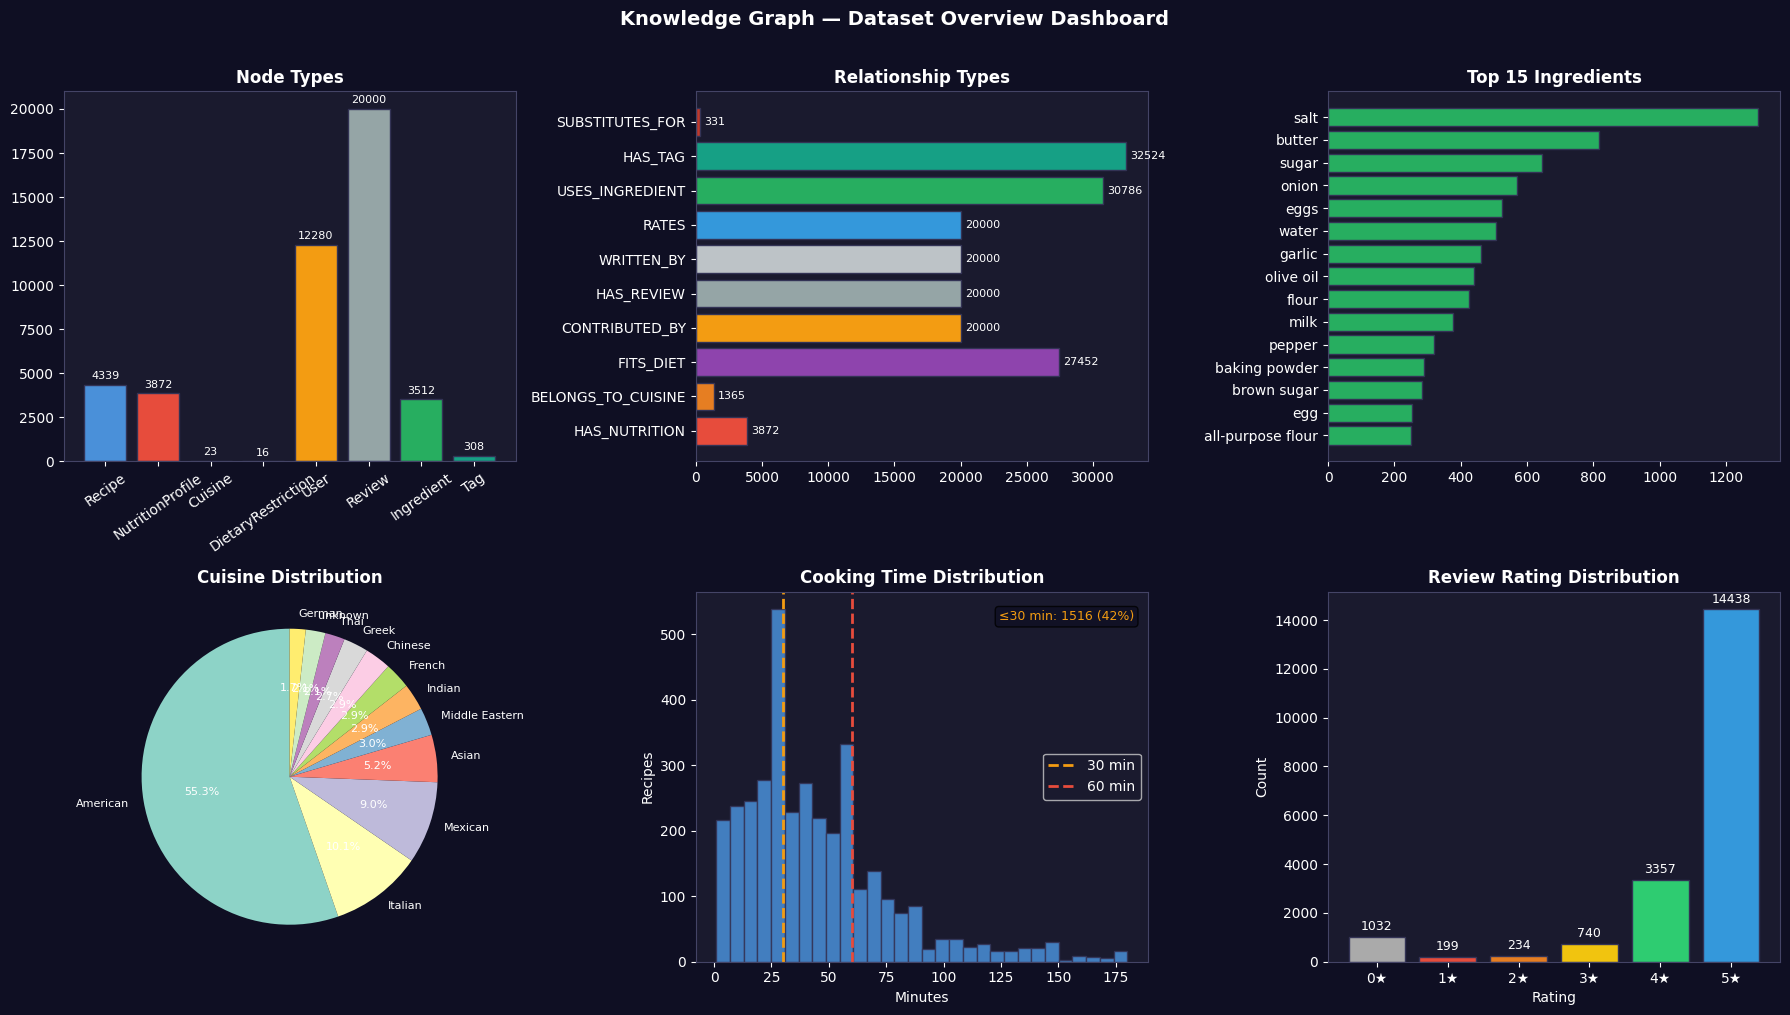

  ✅ Dashboard saved to 'kg_dashboard.png'

═══════════════════════════════════════════════════════
  DEMO: Time-Based Recipe Query
  Query: 'Show me dishes ready in 30 minutes'
═══════════════════════════════════════════════════════

Found 1716 recipes ready in ≤30 minutes:
  1540 with ratings · 176 without ratings in this dataset sample
  Recipe Name                                   Time        Rating  Cuisine           
  ─────────────────────────────────────────────────────────────────────────────────────
  2 ingredient peach sorbet                    5 min  5.0★ (2 reviews)                    
  2 tomato pasta salad                        30 min  5.0★ (4 reviews)                    
  30 minute bean soup for 2                   30 min  5.0★ (2 reviews)                    
  5 minute chili                               5 min  5.0★ (2 reviews)                    
  5 star chocolate chip cookies               25 min  5.0★ (2 reviews)                    
  a different porridge        

In [11]:
# ─── INSTALL DEPENDENCIES IF NEEDED ──────────────────────────────────────────
import subprocess, sys
for pkg in ["pyvis", "matplotlib", "networkx"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import json, os, random
from collections import Counter
from IPython.display import display, HTML

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── LOAD FILES ───────────────────────────────────────────────────────────────
print("Loading kg_triples.json and kg_nodes.json...")
with open("kg_triples.json")  as f: all_triples = json.load(f)
with open("kg_nodes.json")    as f: all_nodes   = json.load(f)
print(f"  Loaded {len(all_triples)} triples, {len(all_nodes)} nodes")

# Build lookup: "Label:name" → node dict (for property access)
node_lookup = {f"{n['label']}:{n['name']}": n for n in all_nodes}

# ─── COLOUR MAPS ──────────────────────────────────────────────────────────────
NODE_COLORS = {
    "Recipe":             "#4A90D9",
    "Ingredient":         "#27AE60",
    "Cuisine":            "#E67E22",
    "DietaryRestriction": "#8E44AD",
    "Tag":                "#16A085",
    "NutritionProfile":   "#E74C3C",
    "User":               "#F39C12",
    "Review":             "#95A5A6",
}
EDGE_COLORS = {
    "USES_INGREDIENT":    "#27AE60",
    "BELONGS_TO_CUISINE": "#E67E22",
    "FITS_DIET":          "#8E44AD",
    "HAS_TAG":            "#16A085",
    "HAS_NUTRITION":      "#E74C3C",
    "HAS_REVIEW":         "#95A5A6",
    "WRITTEN_BY":         "#BDC3C7",
    "CONTRIBUTED_BY":     "#F39C12",
    "RATES":              "#3498DB",
    "SUBSTITUTES_FOR":    "#C0392B",
}

# ═══════════════════════════════════════════════════════════════════════════════
# PART A — INTERACTIVE PYVIS NETWORK
# ═══════════════════════════════════════════════════════════════════════════════
print("\nBuilding interactive network...")
from pyvis.network import Network

VIZ_RECIPES = 6      # number of sample recipes to show
VIZ_HTML    = "kg_network.html"

# Pick sample recipes
recipe_nodes   = [n for n in all_nodes if n["label"] == "Recipe"]
sample_recipes = random.sample(recipe_nodes, min(VIZ_RECIPES, len(recipe_nodes)))
sample_names   = {r["name"] for r in sample_recipes}

# Collect triples touching these recipes — but cap Review nodes per recipe
# to avoid the graph becoming a star with 30+ review spokes
MAX_REVIEWS_PER_RECIPE = 3   # max review nodes shown per recipe

review_count_per_recipe = {}
viz_triples = []
for t in all_triples:
    subj_in = t["subject_name"] in sample_names
    obj_in  = t["object_name"]  in sample_names

    if not subj_in and not obj_in:
        continue

    # Limit HAS_REVIEW edges to MAX_REVIEWS_PER_RECIPE per recipe
    if t["predicate"] == "HAS_REVIEW" and subj_in:
        recipe = t["subject_name"]
        review_count_per_recipe[recipe] = review_count_per_recipe.get(recipe, 0) + 1
        if review_count_per_recipe[recipe] > MAX_REVIEWS_PER_RECIPE:
            continue

    # Also skip WRITTEN_BY and RATES edges for reviews that weren't included
    if t["predicate"] in ("WRITTEN_BY", "RATES"):
        review_name = t["subject_name"]
        # Only include if the review itself was added
        included_reviews = {
            tr["object_name"] for tr in viz_triples if tr["predicate"] == "HAS_REVIEW"
        }
        if review_name not in included_reviews:
            continue

    viz_triples.append(t)

# Collect all involved node keys
involved = set()
for t in viz_triples:
    involved.add(f"{t['subject_label']}:{t['subject_name']}")
    involved.add(f"{t['object_label']}:{t['object_name']}")

# Init pyvis — cdn_resources must be "in_line" (not "inline")
net = Network(
    height="720px", width="100%",
    bgcolor="#1a1a2e", font_color="white",
    cdn_resources="in_line"
)
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -80,
      "springLength": 150,
      "springConstant": 0.05
    },
    "solver": "forceAtlas2Based",
    "stabilization": {"iterations": 200}
  },
  "edges": {
    "font": {"size": 10, "color": "#FFFFFF", "strokeWidth": 3, "strokeColor": "#000000"},
    "smooth": {"type": "curvedCW", "roundness": 0.2}
  },
  "interaction": {"hover": true, "tooltipDelay": 100, "navigationButtons": true}
}
""")

# ── Add nodes ─────────────────────────────────────────────────────────────────
added_nodes = set()
for key in involved:
    parts = key.split(":", 1)
    if len(parts) != 2:
        continue
    label, name = parts
    color = NODE_COLORS.get(label, "#AAAAAA")
    size  = 35 if label == "Recipe" else (20 if label == "Ingredient" else 15)

    node_data = node_lookup.get(key, {})
    props     = node_data.get("properties", {})

    # Build rich tooltip
    tooltip = f"<b style='font-size:14px'>{label}</b><br><b>{name}</b>"
    if label == "Recipe":
        mins    = props.get("minutes", "?")
        rating  = props.get("avg_rating", "?")
        cuisine = props.get("cuisine", "?")
        n_ingr  = props.get("n_ingredients", "?")
        tooltip += f"<br>⏱ <b>{mins} min</b>"
        tooltip += f"<br>⭐ {rating}"
        tooltip += f"<br>🍽 {cuisine}"
        tooltip += f"<br>🧄 {n_ingr} ingredients"
    elif label == "NutritionProfile":
        tooltip += f"<br>🔥 {props.get('calories', '?'):} cal"
        tooltip += f"<br>💪 {props.get('protein', '?'):}g protein"
        tooltip += f"<br>🧈 {props.get('fat', '?'):}g fat"
    elif label == "Review":
        tooltip += f"<br>⭐ {props.get('rating', '?')}"
        tooltip += f"<br>📅 {props.get('date', '?')}"
        text = props.get("text", "")[:80]
        if text:
            tooltip += f"<br><i>'{text}...'</i>"
    elif label == "User":
        tooltip += f"<br>Role: {props.get('role', '?')}"
    elif label == "Ingredient":
        tooltip += f"<br>(ingredient)"
    elif label == "Cuisine":
        tooltip += f"<br>(cuisine)"
    elif label == "DietaryRestriction":
        tooltip += f"<br>(dietary restriction)"

    net.add_node(
        key,
        label=name[:20],
        title=tooltip,
        color={"background": color, "border": "#FFFFFF", "highlight": {"background": color, "border": "#FFD700"}},
        size=size,
        font={"size": 11, "color": "white", "bold": label == "Recipe"}
    )
    added_nodes.add(key)

# ── Add edges with FULL labels (relationship type + minutes) ──────────────────
for t in viz_triples:
    src_key = f"{t['subject_label']}:{t['subject_name']}"
    dst_key = f"{t['object_label']}:{t['object_name']}"
    if src_key not in added_nodes or dst_key not in added_nodes:
        continue

    pred    = t["predicate"]
    color   = EDGE_COLORS.get(pred, "#AAAAAA")
    props   = t.get("properties", {})
    minutes = props.get("minutes")
    rating  = props.get("rating")

    # ── Edge display label: relationship type only (clean, no clutter)
    #    Minutes and rating still appear in the HOVER TOOLTIP
    if pred == "RATES" and rating is not None:
        edge_label = f"⭐ {rating}"
    else:
        edge_label = pred

    # Rich tooltip on hover
    edge_tooltip = f"<b>{pred}</b>"
    if minutes:
        edge_tooltip += f"<br>⏱ {minutes} min"
    if rating:
        edge_tooltip += f"<br>⭐ {rating}"

    net.add_edge(
        src_key, dst_key,
        label=edge_label,
        title=edge_tooltip,
        color={"color": color, "opacity": 0.85},
        arrows="to",
        width=2,
        font={"size": 9, "color": "#FFFFFF", "strokeWidth": 2, "strokeColor": "#000000", "align": "middle"}
    )

net.save_graph(VIZ_HTML)
print(f"  ✅ Saved to '{VIZ_HTML}' — {len(sample_recipes)} recipes, {len(viz_triples)} edges shown")

# Embed inline
try:
    with open(VIZ_HTML) as fh:
        html_content = fh.read()
    display(HTML(f'''<div style="border:2px solid #4A90D9;border-radius:8px;overflow:hidden;">{html_content}</div>'''))
except Exception as e:
    print(f"  (Embed failed: {e} — open {VIZ_HTML} directly)")

# Legend
legend = "<div style='background:#1a1a2e;padding:10px;border-radius:8px;margin-top:6px;'>"
legend += "<span style='color:white;font-weight:bold;'>Nodes: </span>"
for label, color in NODE_COLORS.items():
    legend += f"<span style='background:{color};color:white;padding:2px 8px;border-radius:10px;margin:2px;font-size:11px;'>{label}</span>"
legend += "<br><span style='color:white;font-weight:bold;'>Edges: </span>"
for rel, color in EDGE_COLORS.items():
    legend += f"<span style='background:{color};color:white;padding:2px 6px;border-radius:10px;margin:2px;font-size:10px;'>{rel}</span>"
legend += "</div>"
display(HTML(legend))


# ═══════════════════════════════════════════════════════════════════════════════
# PART B — DASHBOARD CHARTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\nBuilding dashboard charts...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0f0f23")
for ax in axes.flat:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

# Chart 1: Node type distribution
ax1 = axes[0, 0]
lc = Counter(n["label"] for n in all_nodes)
labels_list = list(lc.keys())
counts_list = list(lc.values())
bar_colors  = [NODE_COLORS.get(l, "#AAAAAA") for l in labels_list]
bars = ax1.bar(labels_list, counts_list, color=bar_colors, edgecolor="#333355")
ax1.set_title("Node Types", fontweight="bold")
ax1.tick_params(axis="x", rotation=35)
for bar, cnt in zip(bars, counts_list):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts_list)*0.01,
             str(cnt), ha="center", va="bottom", color="white", fontsize=8)

# Chart 2: Relationship type distribution
ax2 = axes[0, 1]
pc  = Counter(t["predicate"] for t in all_triples)
preds_list  = list(pc.keys())
pcounts_list = list(pc.values())
pcolors_list = [EDGE_COLORS.get(p, "#AAAAAA") for p in preds_list]
bars2 = ax2.barh(preds_list, pcounts_list, color=pcolors_list, edgecolor="#333355")
ax2.set_title("Relationship Types", fontweight="bold")
for bar, cnt in zip(bars2, pcounts_list):
    ax2.text(cnt+max(pcounts_list)*0.01, bar.get_y()+bar.get_height()/2,
             str(cnt), va="center", color="white", fontsize=8)

# Chart 3: Top 15 ingredients
ax3 = axes[0, 2]
ing_triples  = [t for t in all_triples if t["predicate"] == "USES_INGREDIENT"]
top_ing = Counter(t["object_name"] for t in ing_triples).most_common(15)
if top_ing:
    ing_names, ing_cnts = zip(*top_ing)
    ax3.barh(ing_names, ing_cnts, color=NODE_COLORS["Ingredient"], edgecolor="#333355")
    ax3.set_title("Top 15 Ingredients", fontweight="bold")
    ax3.invert_yaxis()
else:
    ax3.text(0.5, 0.5, "Run LLM loop first", ha="center", va="center",
             color="white", transform=ax3.transAxes)
    ax3.set_title("Top 15 Ingredients", fontweight="bold")

# Chart 4: Cuisine distribution
ax4 = axes[1, 0]
cuis_triples = [t for t in all_triples if t["predicate"] == "BELONGS_TO_CUISINE"]
top_cuis = Counter(t["object_name"] for t in cuis_triples).most_common(12)
if top_cuis:
    cnames, ccnts = zip(*top_cuis)
    ccolors = plt.cm.Set3([i/len(cnames) for i in range(len(cnames))])
    wedges, texts, autotexts = ax4.pie(ccnts, labels=cnames, autopct="%1.1f%%",
                                        colors=ccolors, startangle=90,
                                        textprops={"color":"white","fontsize":8})
    for at in autotexts: at.set_color("white")
    ax4.set_title("Cuisine Distribution", fontweight="bold")
else:
    ax4.text(0.5, 0.5, "No cuisines found in tags", ha="center", va="center",
             color="white", transform=ax4.transAxes)
    ax4.set_title("Cuisine Distribution", fontweight="bold")

# Chart 5: Cooking time histogram
ax5 = axes[1, 1]
recipe_nodes_list = [n for n in all_nodes if n["label"] == "Recipe"]
mins_vals = []
for n in recipe_nodes_list:
    m = n["properties"].get("minutes", 0)
    try:
        m = int(float(m))
        if 0 < m <= 180:
            mins_vals.append(m)
    except: pass
if mins_vals:
    ax5.hist(mins_vals, bins=30, color=NODE_COLORS["Recipe"], edgecolor="#333355", alpha=0.85)
    ax5.axvline(30, color="#F39C12", linestyle="--", linewidth=2, label="30 min")
    ax5.axvline(60, color="#E74C3C", linestyle="--", linewidth=2, label="60 min")
    ax5.set_title("Cooking Time Distribution", fontweight="bold")
    ax5.set_xlabel("Minutes")
    ax5.set_ylabel("Recipes")
    ax5.legend(facecolor="#1a1a2e", labelcolor="white")
    under30 = sum(1 for m in mins_vals if m <= 30)
    ax5.text(0.97, 0.95, f"≤30 min: {under30} ({100*under30//len(mins_vals)}%)",
             transform=ax5.transAxes, ha="right", va="top", color="#F39C12", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#0f0f23", alpha=0.8))
else:
    ax5.text(0.5, 0.5, "No minutes data", ha="center", va="center",
             color="white", transform=ax5.transAxes)
    ax5.set_title("Cooking Time Distribution", fontweight="bold")

# Chart 6: Rating distribution
ax6 = axes[1, 2]
review_nodes = [n for n in all_nodes if n["label"] == "Review"]
ratings = [n["properties"].get("rating") for n in review_nodes if n["properties"].get("rating") is not None]
if not ratings:
    ratings = [n["properties"].get("avg_rating") for n in recipe_nodes_list
               if n["properties"].get("avg_rating", 0) > 0]
    ax6.set_title("Recipe Avg Rating Distribution", fontweight="bold")
else:
    ax6.set_title("Review Rating Distribution", fontweight="bold")
if ratings:
    rc = Counter(round(float(r)) for r in ratings if r is not None)
    xs = sorted(rc.keys())
    ys = [rc[x] for x in xs]
    star_colors = ["#E74C3C","#E67E22","#F1C40F","#2ECC71","#3498DB"]
    bc = [star_colors[min(int(x)-1,4)] if 1<=x<=5 else "#AAAAAA" for x in xs]
    bars6 = ax6.bar([f"{x}★" for x in xs], ys, color=bc, edgecolor="#333355")
    ax6.set_xlabel("Rating")
    ax6.set_ylabel("Count")
    for bar, cnt in zip(bars6, ys):
        ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(ys)*0.01,
                 str(cnt), ha="center", va="bottom", color="white", fontsize=9)
else:
    ax6.text(0.5, 0.5, "No ratings yet", ha="center", va="center",
             color="white", transform=ax6.transAxes)

plt.suptitle("Knowledge Graph — Dataset Overview Dashboard",
             fontsize=14, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.savefig("kg_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f23", edgecolor="none")
plt.show()
print("  ✅ Dashboard saved to 'kg_dashboard.png'")


# ═══════════════════════════════════════════════════════════════════════════════
# PART C — TIME-BASED RECIPE QUERY DEMO
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("  DEMO: Time-Based Recipe Query")
print("  Query: 'Show me dishes ready in 30 minutes'")
print("═"*55)

MAX_MINUTES = 30

# ── Build lookups from nodes ───────────────────────────────────────────────────

# Recipe properties (minutes, cuisine, n_ingredients etc.)
recipe_prop_lookup = {
    n["name"]: n["properties"]
    for n in all_nodes if n["label"] == "Recipe"
}

# Compute avg_rating and num_ratings PER RECIPE from Review nodes
# (more accurate than Recipe.avg_rating which may be 0 if computed on a small sample)
from collections import defaultdict
recipe_ratings = defaultdict(list)

# Source 1: Review nodes → their rating property
for n in all_nodes:
    if n["label"] == "Review":
        rating = n["properties"].get("rating")
        if rating is not None:
            try:
                rating = float(rating)
                # Review name format: "review_{user_id}_{recipe_name_prefix}"
                # Find which recipe this review belongs to via RATES triples
                pass   # handled below via triples
            except: pass

# Source 2: RATES triples have {rating, recipe_name} directly
for t in all_triples:
    if t["predicate"] == "RATES":
        recipe_name = t["object_name"]
        rating_val  = t.get("properties", {}).get("rating")
        if rating_val is not None:
            try:
                recipe_ratings[recipe_name].append(float(rating_val))
            except: pass

# Source 3: HAS_REVIEW → Review node → rating (catches reviews not in RATES)
review_ratings = {
    n["name"]: n["properties"].get("rating")
    for n in all_nodes if n["label"] == "Review"
}
for t in all_triples:
    if t["predicate"] == "HAS_REVIEW":
        recipe_name  = t["subject_name"]
        review_name  = t["object_name"]
        rating_val   = review_ratings.get(review_name)
        if rating_val is not None:
            try:
                recipe_ratings[recipe_name].append(float(rating_val))
            except: pass

# Source 4: Recipe node avg_rating as final fallback
for name, props in recipe_prop_lookup.items():
    if name not in recipe_ratings:
        avg = props.get("avg_rating", 0)
        num = props.get("num_ratings", 0)
        if avg and float(avg) > 0:
            recipe_ratings[name] = [float(avg)] * max(1, int(num))

# Compute final avg per recipe
def get_avg_rating(recipe_name):
    ratings_list = recipe_ratings.get(recipe_name, [])
    if not ratings_list:
        return None
    return round(sum(ratings_list) / len(ratings_list), 1)

# ── Find qualifying recipes via edge minutes property ─────────────────────────
quick_recipe_names = set()
for t in all_triples:
    props = t.get("properties", {})
    mins  = props.get("minutes")
    if mins is not None:
        try:
            if int(float(mins)) <= MAX_MINUTES and t["subject_label"] == "Recipe":
                quick_recipe_names.add(t["subject_name"])
        except: pass

# ── Build result rows ──────────────────────────────────────────────────────────
results = []
for name in quick_recipe_names:
    props    = recipe_prop_lookup.get(name, {})
    mins_val = props.get("minutes", "?")
    try:    mins_display = int(float(mins_val))
    except: mins_display = "?"

    avg_rating  = get_avg_rating(name)
    num_ratings = len(recipe_ratings.get(name, []))

    results.append({
        "name":        name,
        "minutes":     mins_display,
        "avg_rating":  avg_rating,
        "num_ratings": num_ratings,
        "cuisine":     props.get("cuisine", "Unknown"),
        "calories":    props.get("calories", 0),
    })

# Sort: rated recipes first (by rating desc), then unrated alphabetically
results.sort(key=lambda x: (
    0 if x["avg_rating"] is not None else 1,
    -float(x["avg_rating"] or 0),
    x["name"]
))

rated   = [r for r in results if r["avg_rating"] is not None]
unrated = [r for r in results if r["avg_rating"] is None]
print(f"\nFound {len(results)} recipes ready in ≤{MAX_MINUTES} minutes:")
print(f"  {len(rated)} with ratings · {len(unrated)} without ratings in this dataset sample")
print(f"  {'Recipe Name':<42} {'Time':>7}  {'Rating':>12}  {'Cuisine':<18}")
print("  " + "─" * 85)
for r in results[:25]:
    mins_str   = f"{r['minutes']} min" if r['minutes'] != '?' else '? min'
    if r["avg_rating"] is not None:
        rating_str = f"{r['avg_rating']}★ ({r['num_ratings']} reviews)"
    else:
        rating_str = "no reviews"
    print(f"  {r['name'][:41]:<42} {mins_str:>7}  {rating_str:>12}  {str(r['cuisine'])[:17]:<18}")
if len(results) > 25:
    print(f"  ... and {len(results)-25} more")

print(f"""
✅ 'minutes' on every edge enables this filter from the graph.
   Neo4j Cypher query (Phase 3):

   MATCH (r:Recipe)-[e]->()
   WHERE e.minutes <= {MAX_MINUTES}
   RETURN DISTINCT r.name, r.avg_rating, r.cuisine, e.minutes
   ORDER BY r.avg_rating DESC
""")
